In [1]:
import json
from pathlib import Path
from typing import Dict, Tuple, Sequence
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Basic metric helpers

In [2]:
def recall_at_k(sim: np.ndarray, k: int = 1) -> float:
    """
    Exact Recall@K given a full similarity matrix.
    sim shape: [N_text, N_image] where the i-th caption's
    matching image is also index i.
    """
    topk = np.argpartition(-sim, k - 1, axis=1)[:, :k]
    hits = np.any(topk == np.arange(sim.shape[0])[:, None], axis=1)
    return float(hits.mean()) * 100
        

def median_rank(sim: np.ndarray) -> int:
    ranks = np.argsort(-sim, axis=1)
    row_r = [int(np.where(ranks[i] == i)[0][0] + 1) for i in range(len(sim))]
    return int(np.median(row_r))


# Low-RAM chunked Recall / median

In [ ]:
def chunked_metrics(
    txt_emb: np.ndarray,
    img_emb: np.ndarray,
    k_vals: Sequence[int] = (1, 5, 10),
    chunk: int = 2000,
) -> Dict[str, float]:
    """
    Compute Recall@K and median rank without forming the full NxN matrix.
    """
    n = txt_emb.shape[0]
    correct = {k: np.zeros(n, dtype=bool) for k in k_vals}
    ranks = np.empty(n, dtype=np.int32)
    for s in range(0, n, chunk):
        e = min(s + chunk, n)
        sim = txt_emb[s:e] @ img_emb.T           # (chunk, n)
        rows = np.arange(s, e)[:, None]
        for k in k_vals:
            topk = np.argpartition(-sim, k - 1, axis=1)[:, :k]
            correct[k][s:e] = np.any(topk == rows, axis=1)
        ranks[s:e] = np.sum(sim >= sim[np.arange(e - s), rows.T], axis=1)
        del sim
    out = {f"R@{k}": round(correct[k].mean() * 100, 2) for k in k_vals}
    out["median_rank"] = int(np.median(ranks))
    return out

# Utilities to load experiment folders

In [ ]:
from pathlib import Path
import json, pandas as pd

EXP_ROOT = Path("experiments")         

def load_metrics(exp_path: Path):
    m = json.loads((exp_path / "metrics.json").read_text())
    c = json.loads((exp_path / "config.json").read_text())
    return m, c

def collect_runs(root: Path = EXP_ROOT) -> pd.DataFrame:
    rows = []
    for p in root.iterdir():
        if (p / "metrics.json").exists():
            met, cfg = load_metrics(p)
            rows.append({**met, **cfg, "folder": p.name})
    if not rows:
        print("No experiments found in", root)
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("folder").reset_index(drop=True)

df_runs = collect_runs()
df_runs.head()


,R@1,R@5,R@10,median_rank,device,model,pretrained,batch,max_samples,parquet,folder
0,89.00,97.00,98.0,1,cpu,RN50,openai,64,100,C:\Users\steph\OneDrive\Desktop\data\metadata....,RN50_20250623_213349
1,78.00,96.00,98.0,1,cpu,RN50,openai,64,100,C:\Users\steph\OneDrive\Desktop\data\metadata....,RN50_20250623_213537
2,48.35,76.55,85.2,2,cpu,RN50,openai,64,2000,C:\Users\steph\OneDrive\Desktop\data\metadata....,RN50_20250623_214602


# Simple bar-plot of Recall@

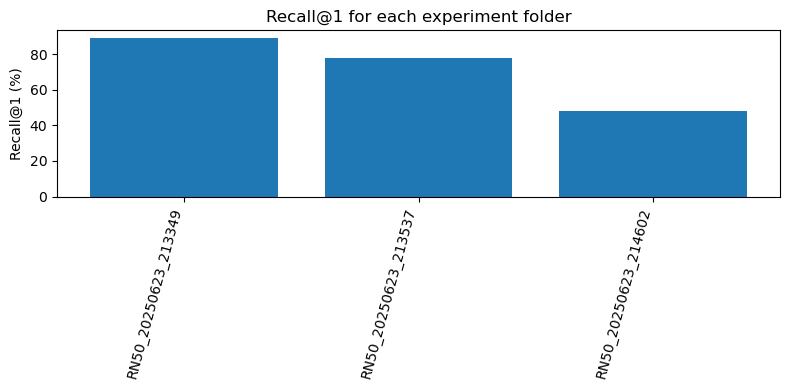

In [10]:
if not df_runs.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(df_runs["folder"], df_runs["R@1"])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Recall@1 (%)")
    plt.title("Recall@1 for each experiment folder")
    plt.tight_layout()
    plt.show()


# Example: recompute metrics for a run in chunks

In [11]:
run_id = df_runs.iloc[0]["folder"]   
run_path = EXP_ROOT / run_id

img = np.load(run_path / "img_embs.npy").astype("float32")
txt = np.load(run_path / "txt_embs.npy").astype("float32")

new_metrics = chunked_metrics(txt, img, chunk=1000)
print("Recomputed metrics:", new_metrics)

Recomputed metrics: {'R@1': 89.0, 'R@5': 97.0, 'R@10': 98.0, 'median_rank': 1}


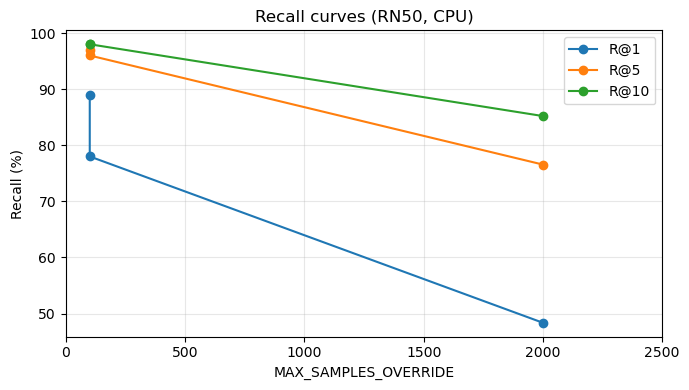

In [16]:
import json, matplotlib.pyplot as plt, pandas as pd
from pathlib import Path

EXP_ROOT = Path("experiments")
LOW, HIGH = 0, 2500

rows = []
for p in EXP_ROOT.iterdir():
    m, c = p / "metrics.json", p / "config.json"
    if m.exists() and c.exists():
        met = json.loads(m.read_text())
        cfg = json.loads(c.read_text())
        samples = cfg.get("max_samples") or cfg.get("samples") or None
        if samples is not None and LOW <= samples <= HIGH:
            rows.append({"samples": samples, **met})

df = pd.DataFrame(rows).sort_values("samples")
if df.empty:
    print("No runs in range")
else:
    plt.figure(figsize=(7,4))
    for k in ("R@1","R@5","R@10"):
        plt.plot(df["samples"], df[k], marker="o", label=k)
    plt.xlim(LOW, HIGH)
    plt.xlabel("MAX_SAMPLES_OVERRIDE")
    plt.ylabel("Recall (%)")
    plt.title("Recall curves (RN50, CPU)")
    plt.grid(alpha=.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
